In [136]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [137]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [138]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [139]:
raw_data_url="https://gist.githubusercontent.com/anu-006/95eea119d84814494da73947c8619421/raw/fec62bef1ecc5b468c87c282d6f54fd91bb35a1b/Food_Delivery_Times"

In [140]:
data=pd.read_csv(raw_data_url)

In [141]:
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [142]:
data.shape

(1000, 9)

In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [144]:
(data.isnull().sum()/len(data))*100

,0
Order_ID,0.0
Distance_km,0.0
Weather,3.0
Traffic_Level,3.0
Time_of_Day,3.0
Vehicle_Type,0.0
Preparation_Time_min,0.0
Courier_Experience_yrs,3.0
Delivery_Time_min,0.0


In [145]:
data.duplicated().sum()

np.int64(0)

In [146]:
data.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [147]:
corr=data.corr(numeric_only=True)

<Axes: >

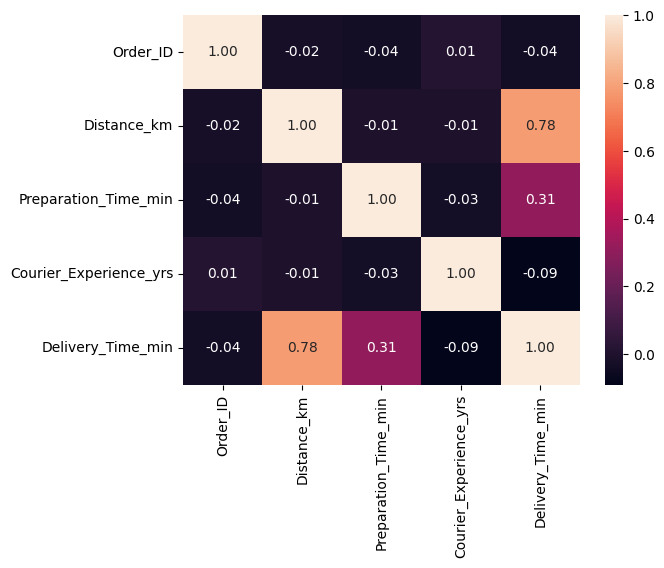

In [148]:
sns.heatmap(corr,annot=True,fmt='.2f')

In [149]:
data.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

## Data Preprocessing

In [150]:
num

['Distance_km',
 'Preparation_Time_min',
 'Courier_Experience_yrs',
 'Delivery_Time_min']

In [151]:
cat

['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

In [152]:
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [153]:
data.drop(columns=['Order_ID'],inplace=True)

In [154]:
num=[ 'Distance_km',  'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min']

In [155]:
cat=['Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type',]

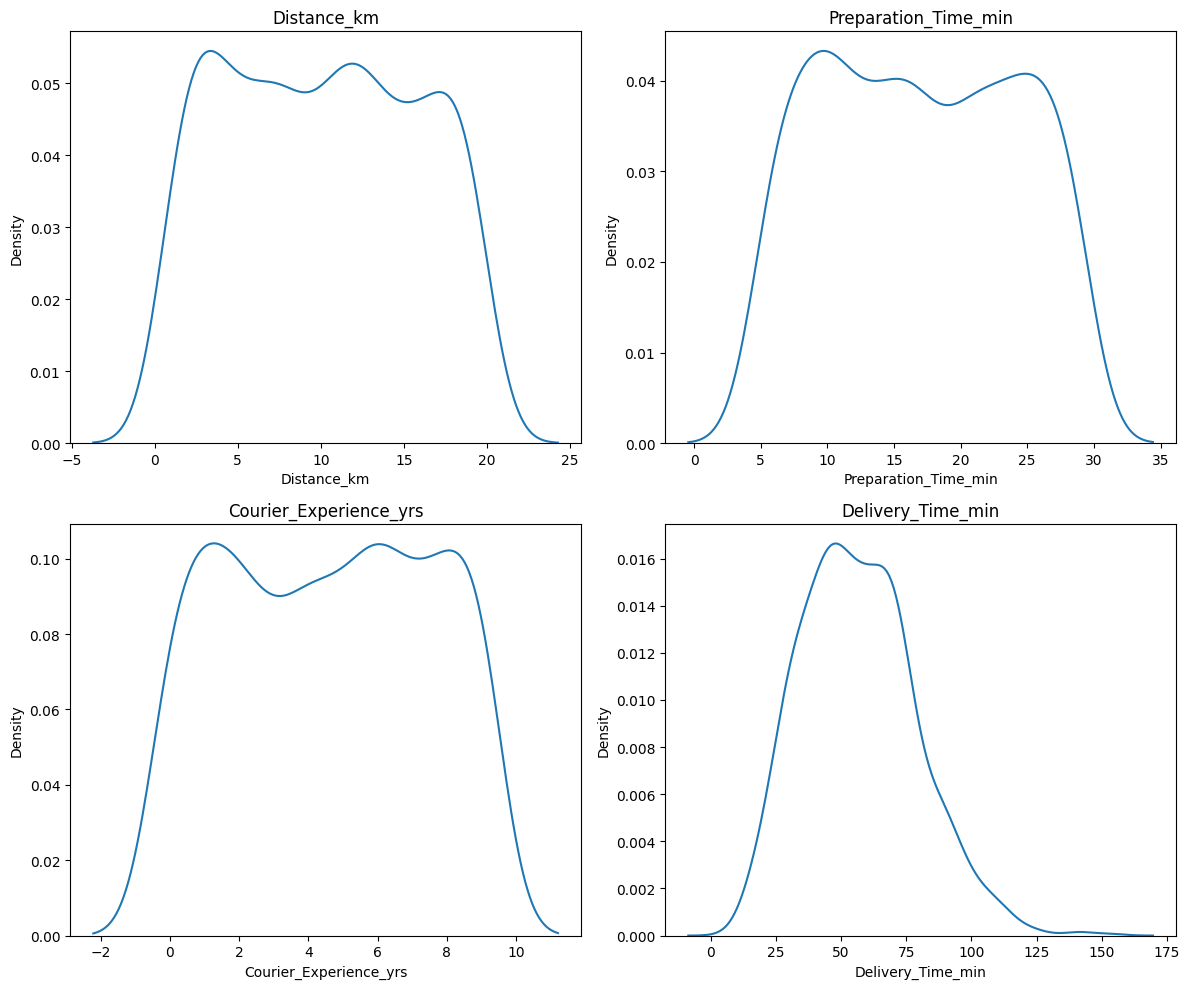

In [156]:
plt.figure(figsize=(12,10))

for index,col in enumerate(num):

  plt.subplot(2,2,index+1)
  sns.kdeplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()


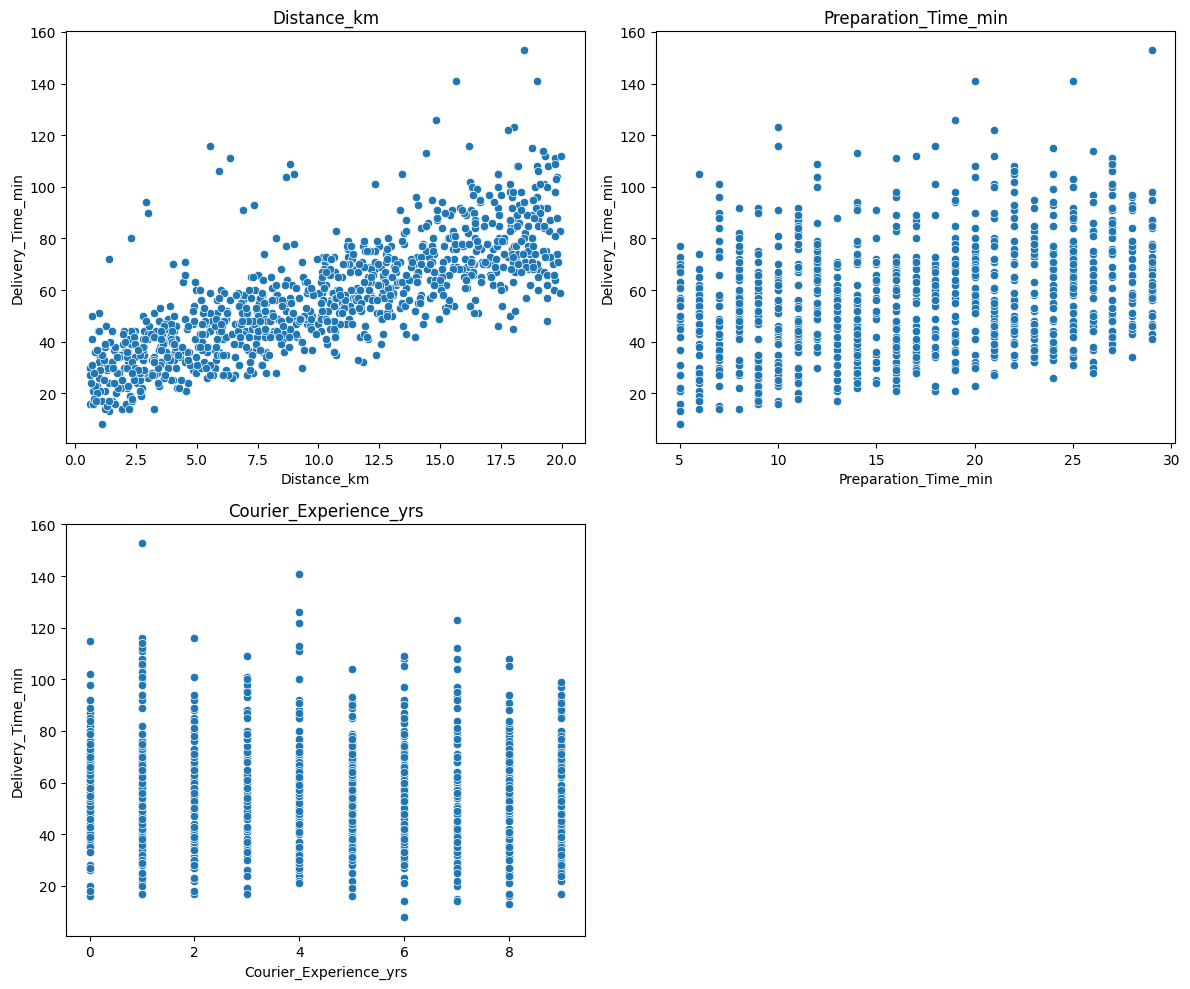

In [157]:
plt.figure(figsize=(12,10))

# Filter out 'Delivery_Time_min' from the 'num' list for the x-axis features
features_for_scatter = [col for col in num if col != 'Delivery_Time_min']

for index,col in enumerate(features_for_scatter):

  plt.subplot(2,2,index+1)
  sns.scatterplot(x=data[col],y=data['Delivery_Time_min'])
  plt.title(col)
  plt.tight_layout()
plt.show()

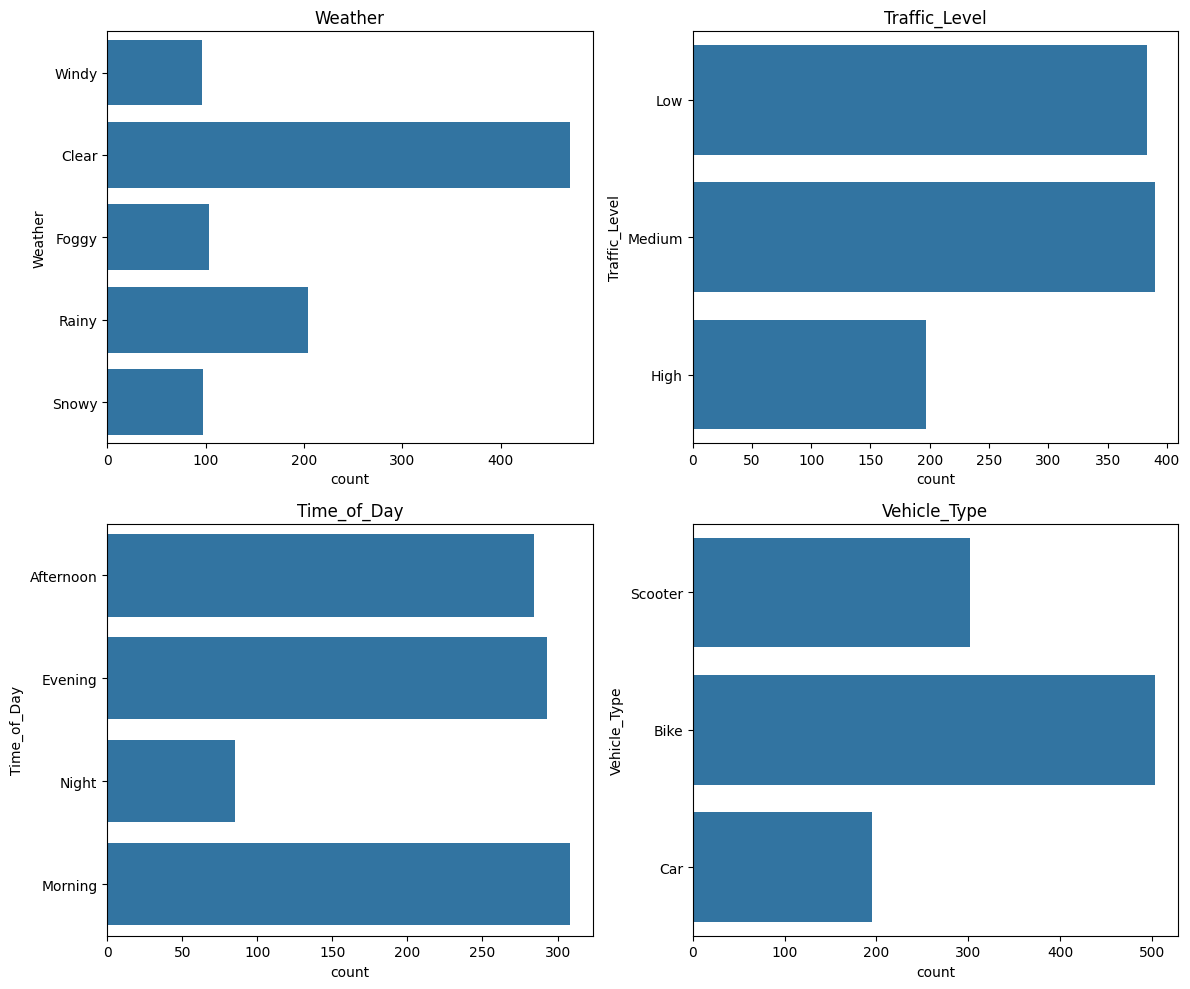

In [158]:
plt.figure(figsize=(12,10))

for index,col in enumerate(cat):

  plt.subplot(2,2,index+1)
  sns.countplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

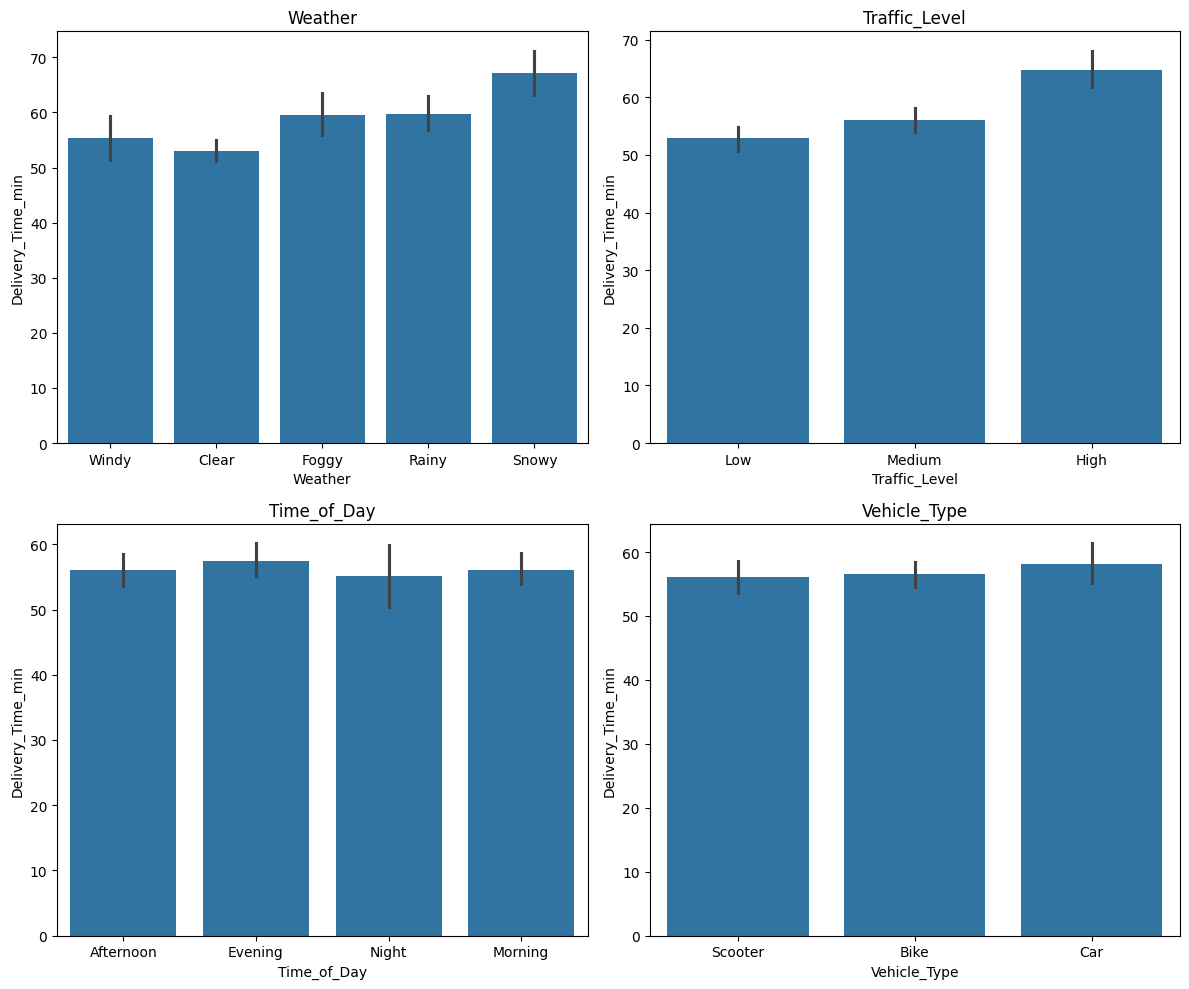

In [159]:
plt.figure(figsize=(12,10))

for index,col in enumerate(cat):

  plt.subplot(2,2,index+1)
  sns.barplot(x=data[col],y=data['Delivery_Time_min'])
  plt.title(col)
  plt.tight_layout()
plt.show()

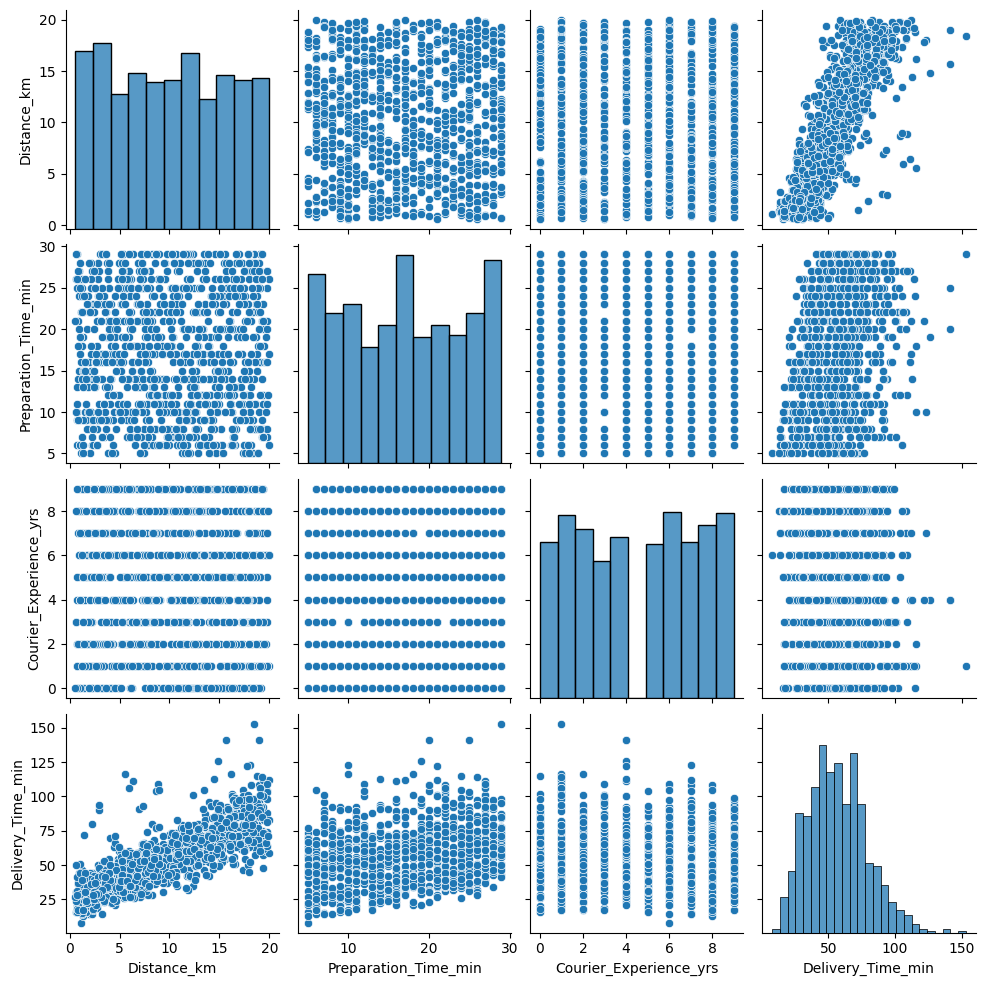

In [160]:
sns.pairplot(data[num])

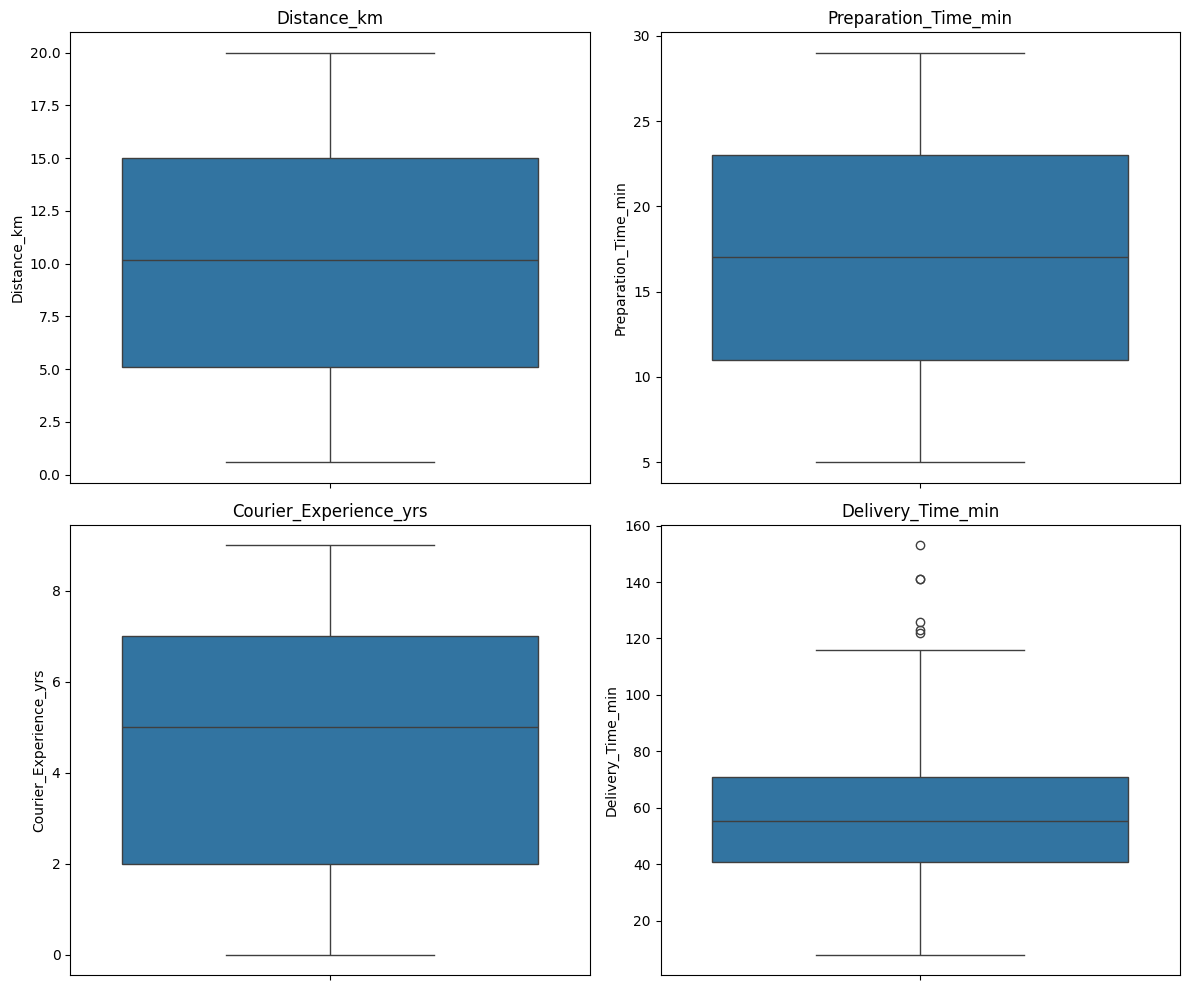

In [161]:
plt.figure(figsize=(12,10))

for index,col in enumerate(num):

  plt.subplot(2,2,index+1)
  sns.boxplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

In [162]:
Q1 = data['Delivery_Time_min'].quantile(0.25)
Q3 = data['Delivery_Time_min'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

data['Delivery_Time_min'] = np.where(
    data['Delivery_Time_min'] < lower_limit,
    lower_limit,
    np.where(
        data['Delivery_Time_min'] > upper_limit,
        upper_limit,
        data['Delivery_Time_min']
    )
)

In [163]:
for i in num:
  print(f'{i} : ',data[i].skew())

Distance_km :  0.038840474919290116
Preparation_Time_min :  0.030008161330597263
Courier_Experience_yrs :  -0.029086829121382836
Delivery_Time_min :  0.37760713693438686


In [164]:
# Separate features (X) and target (y)
X = data.drop(columns=['Delivery_Time_min'])
y = data['Delivery_Time_min']

# Identify numerical and categorical features for preprocessing
numerical_features = [col for col in num if col != 'Delivery_Time_min']
cat_ohe=['Weather','Time_of_Day', 'Vehicle_Type']
cat_ordinal=['Traffic_Level']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')),
                               ('scaler', StandardScaler())]), numerical_features),
        ('cat_ohe', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                   ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_ohe),
        ('cat_ordinal', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('ordinal', OrdinalEncoder(categories=[['Low','Medium','High']]))]), cat_ordinal)
    ])



In [165]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [166]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

In [167]:
metrics = {
    'MAE': mean_absolute_error,
    'RMSE': lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    'R2 Score': r2_score
}

In [168]:
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', model)])



In [169]:
results = {}

for name, pipeline in pipelines.items():
    print(f"\nTraining {name}...")
    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    model_metrics = {}
    for metric_name, metric_func in metrics.items():
        model_metrics[metric_name] = metric_func(y_test, y_pred)

    results[name] = model_metrics


# Display results
print("\n--- Model Evaluation Results ---")
for name, model_metrics in results.items():
    print(f"\n{name}:")
    for metric_name, value in model_metrics.items():
        print(f"  {metric_name}: {value:.4f}")


Training Linear Regression...

Training Decision Tree Regressor...

Training Random Forest Regressor...

Training XGBoost Regressor...

--- Model Evaluation Results ---

Linear Regression:
  MAE: 6.0237
  RMSE: 8.8237
  R2 Score: 0.8248

Decision Tree Regressor:
  MAE: 10.6250
  RMSE: 15.2031
  R2 Score: 0.4799

Random Forest Regressor:
  MAE: 6.8745
  RMSE: 9.5855
  R2 Score: 0.7932

XGBoost Regressor:
  MAE: 7.9536
  RMSE: 11.0032
  R2 Score: 0.7276


In [170]:

rf_model = pipelines['Random Forest Regressor'].named_steps['regressor']
feature_importances = rf_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.Series(feature_importances, index=feature_names)


print("Random Forest Feature Importances:")
print(importance_df.sort_values(ascending=False))

Random Forest Feature Importances:
num__Distance_km                  0.701833
num__Preparation_Time_min         0.148562
num__Courier_Experience_yrs       0.038319
cat_ordinal__Traffic_Level        0.029412
cat_ohe__Weather_Clear            0.011503
cat_ohe__Weather_Snowy            0.010021
cat_ohe__Time_of_Day_Evening      0.008269
cat_ohe__Weather_Foggy            0.007599
cat_ohe__Vehicle_Type_Car         0.007116
cat_ohe__Weather_Rainy            0.006921
cat_ohe__Vehicle_Type_Bike        0.006209
cat_ohe__Time_of_Day_Afternoon    0.006118
cat_ohe__Vehicle_Type_Scooter     0.005823
cat_ohe__Time_of_Day_Morning      0.005451
cat_ohe__Time_of_Day_Night        0.003986
cat_ohe__Weather_Windy            0.002859
dtype: float64


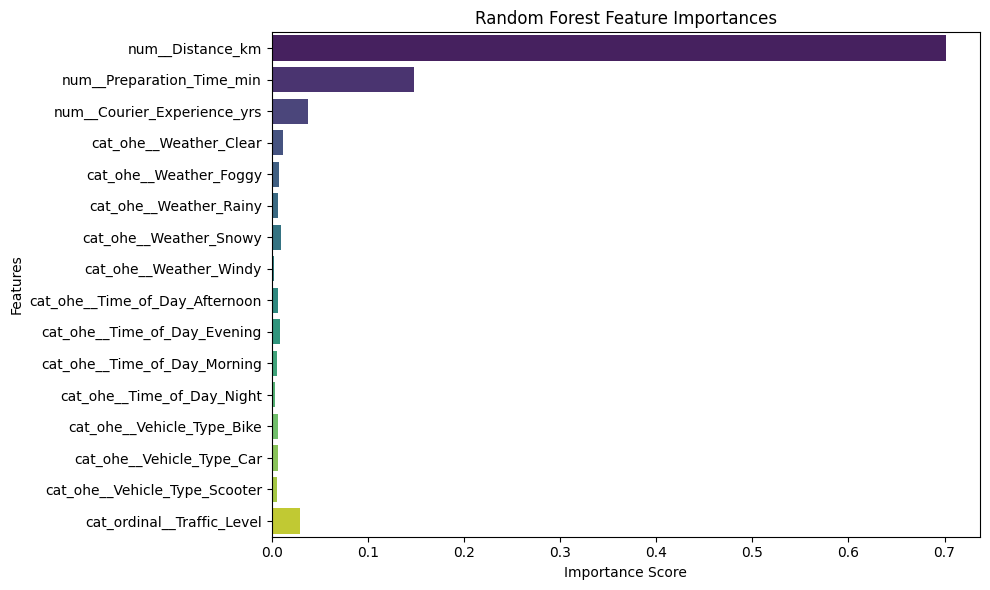

In [171]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df.values, y=importance_df.index, hue=importance_df.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Linear regression performs best with r2_score 0.82